In [1]:
import sys
sys.path.append("../utils")
import utils as ut
import preprocess as pc
import hydro_storage as hs
import energy_analysis as ea
import plot_config as pco
import pandas as pd
import xarray as xr
from tqdm import tqdm
import glob
from datetime import timedelta
import numpy as np
import matplotlib.pyplot as plt
import string

# Functions
These are functions from the utils package hydro_storage, which calculate the operation of the hydropower dispatch model. In order to perform this sensitivity analysis, we need to tweak the code to allow for changes in the assumptions

In [2]:
def calculate_storage_net_load_tweaked(inflow_t, net_load_t, storage_t_minus_1, net_load_thresh, mean,std,storage_max,capacity_thresh,upper_tweak,middle_tweak, lower_tweak):
    """
    Calculates the storage level in hydro reservoirs, and returns the storage level and adjusted net load at time t 
    Args: 
        inflow_t: inflow at time t (float)
        net_load_t: net load at time t, without storage adjustment (float)
        storage_t_minus_1: storage level at time t-1 (float)
        net_load_thresh: threshold at which net_load becomes critical enough that storage is needed (float)
        storage_thresh: values at time t of different storage levels, to create a mean and standard deviation (np.arr())
    """
    #fill storage unless its full
    if storage_t_minus_1 >= storage_max:
        storage_t = storage_t_minus_1
        net_load_t = net_load_t - inflow_t
    else:
        storage_t = storage_t_minus_1 + inflow_t #fill storage with inflow at time t
    if net_load_t-net_load_thresh > 0: # if net load is above threshold, we need to adjust the storage and net load levels
        #calculate mean and std dev storage thresholds for time t
        upper_storage_thresh = mean + std
        lower_storage_thresh = mean - std
        # case 1: storage is fuller than average for that time of year 
        if  storage_t - upper_storage_thresh > 0 :
            # we remove either the necessary net load to go under the threshold (if it is below the operation capacity), 
            # or if there isn't enough storage, the remaining storage until the upper storage threshold is reached
            take_from_storage = min((net_load_t-net_load_thresh),capacity_thresh*upper_tweak,storage_t-upper_storage_thresh)
            storage_t = storage_t - take_from_storage
            net_load_t = net_load_t - take_from_storage
        # case 2: storage is typical for that time of year
        if storage_t - upper_storage_thresh <= 0 and storage_t - lower_storage_thresh > 0:
            # we remove either the half of the necessary net load to go under the threshold (if it is below the operation capacity), 
            # or if there isn't enough storage, the remaining storage between the upper and lower threshold
            take_from_storage = min((net_load_t-net_load_thresh), capacity_thresh*middle_tweak, storage_t-lower_storage_thresh) #(upper_storage_thresh - lower_storage_thresh)/(7*24)
            storage_t = storage_t - take_from_storage
            net_load_t = net_load_t - take_from_storage 

        #  case 3: storage is emptier than average for that time of year
        if storage_t - lower_storage_thresh <= 0 and storage_t >0:
            # we remove either the a quarter of the necessary net load to go under the threshold (if it is below the operation capacity), 
            # or if there isn't enough storage, the remaining storage 
            take_from_storage = min((net_load_t-net_load_thresh), capacity_thresh*lower_tweak,storage_t)
            storage_t = storage_t - take_from_storage
            net_load_t = net_load_t - take_from_storage 

    storage_out = storage_t
    net_load_out = net_load_t
    return storage_out,net_load_out

In [3]:
def calculate_storage_net_load_country_tweaked(net_load, hydro_inflow,storage_roll,storage_max,starting_storage,net_load_thresh_country,max_capac,upper_tweak,middle_tweak, lower_tweak):
    """
    Calculates the storage effects for all countries.
    """
    storage = []
    net_load_adj = []
    for country in net_load.country:
        # select country-specific net load
        net_load_country = net_load.sel(country=country).values
        if country.values in hydro_inflow.country.values:
            #select other country-specific variables
            hif_country = hydro_inflow.sel(country=country)
            hif_country = hif_country.where(hif_country >0, 0).values
            #net_load_thresh_country = qu.sel(country=country).item()
            capacity_thresh_country = max_capac.sel(country=country).item()
            storage_thresh_country = storage_roll.sel(country=country).groupby("time.dayofyear")
            storage_thresh_mean = storage_thresh_country.mean().values
            storage_thresh_std = storage_thresh_country.std().values
            storage_max_country = storage_max.sel(country=country).item()
            # loop over time
            storage_country = [starting_storage.sel(country=country).item()] #storage at time 0 stays the same
            net_load_adj_country = [net_load_country[0]] #adjusted net load at time 0 stays the same
            for i in (range(1, len(net_load_country))):
                doy = int(i%8760/24) # day of year value is hour of year value /24
                if i ==0:
                    continue
                else:
                    #calculate adjusted net load and storage values
                    storage_t, net_load_adj_t = calculate_storage_net_load_tweaked(
                        hif_country[i],  
                        net_load_country[i], 
                        storage_country[i-1], 
                        net_load_thresh_country, 
                        storage_thresh_mean[doy],
                        storage_thresh_std[doy],
                        storage_max_country,
                        capacity_thresh_country,
                        upper_tweak,middle_tweak, lower_tweak
                    )
                    storage_country.append(storage_t)
                    net_load_adj_country.append(net_load_adj_t)
            storage.append(storage_country)
            net_load_adj.append(net_load_adj_country)
        else:
            storage.append(list(np.zeros(len(net_load_country)))) # no storage if no hydro
            net_load_adj.append(net_load_country)
    net_load_adj = xr.DataArray(net_load_adj,dims=["country","time"], coords={"time":net_load.time,"country":net_load.country})
    storage = xr.DataArray(storage,dims=["country","time"], coords={"time":net_load.time,"country":net_load.country})
    out_ds = storage.to_dataset(name="storage")
    out_ds["net_load_adjusted"] = net_load_adj
    return out_ds

In [4]:
def storage_net_load_all_dims_tweaked(abs_vars_tech_sum,techs,hydro_inflow_full,storage_roll,storage_max,starting_storage,boost,upper_tweak,middle_tweak, lower_tweak):
    """
    Calculates storage effects over all dimensions of the net load dataset (technology capacity scenario, heating scenario and member)"""
    adjusted_net_load_capac = []
    for capacity_scenario in tqdm(abs_vars_tech_sum.capacity_scenario.values):
        adjusted_net_load_heat_scenario = []
        for heat_scenario in techs["heating-demand"]:
            adjusted_net_load_mem = []
            # 75th quantile, used as the threshold for when hydro storage is needed
            #qu = abs_vars_tech_sum.sel(capacity_scenario=capacity_scenario,heating_scenario=heat_scenario).quantile(0.75,dim=("member","time"))
            for member in abs_vars_tech_sum.member.values:
                #select specific realization of net load and inflow datasets
                net_load_specific = abs_vars_tech_sum.sel(capacity_scenario=capacity_scenario,member=member,heating_scenario=heat_scenario)
                hydro_inflow = hydro_inflow_full.sel(capacity_scenario=capacity_scenario,member=member,heating_scenario=heat_scenario)
                max_capac = hs.get_hydro_capac(hydro_inflow.country.values).max_capac
                # calculate adjusted net load and storage
                if len(boost) == 0:
                    adjusted_net_load=calculate_storage_net_load_country_tweaked(net_load_specific, hydro_inflow,storage_roll,storage_max,starting_storage,0,max_capac,upper_tweak,middle_tweak, lower_tweak)
                else:
                    adjusted_net_load=calculate_storage_net_load_country_tweaked(net_load_specific, hydro_inflow,storage_roll,storage_max,starting_storage.sel(capacity_scenario=capacity_scenario,heating_scenario=heat_scenario),0,max_capac,upper_tweak,middle_tweak, lower_tweak)
                adjusted_net_load_mem.append(adjusted_net_load)
            adjusted_net_load_heat_scenario.append(xr.concat(adjusted_net_load_mem,dim=pd.Index(abs_vars_tech_sum.member.values, name="member")))
        adjusted_net_load_capac.append(xr.concat(adjusted_net_load_heat_scenario,dim=pd.Index(list(techs["heating-demand"].keys()), name="heating_scenario")))
    return xr.concat(adjusted_net_load_capac,dim=pd.Index(abs_vars_tech_sum.capacity_scenario.values, name="capacity_scenario"))

In [5]:
colors_nl = colors = [pco.colors[0],"rosybrown","gold","wheat","yellow"]
colors_storage = ["slategray",pco.colors[2],"lightsteelblue"]

def plot_hydro_storage(countries=["France","Norway"],fsize=(7,3),heating_scenario = "fully_electrified",capacity_scenario = "future",scenario = "historical"):
    f1,ax1=plt.subplots(1,int(len(countries)),figsize=fsize,sharex=True)
    f2,ax2=plt.subplots(1,int(len(countries)),figsize=fsize,sharex=True)
    b_adjust = 0.25
    ax_iter = [0]
    for i,country in enumerate(countries):
        net_ax = ax1[i%5]
        stor_ax = ax2[i%5]
        for test in [0,1,2]:
            nl_hydro_here = net_load_hydro_by_country[f'test{test}'].sel(heating_scenario=heating_scenario,capacity_scenario=capacity_scenario,country=country)
            # plot net load (with hydro storage)
            nl_hydro_nl = nl_hydro_here.net_load_adjusted.groupby("time.dayofyear")
            mn = nl_hydro_nl.mean(("time","member"))
            std = nl_hydro_nl.std(("time","member"))
            mn.plot(ax=net_ax,zorder=3,color=colors_nl[test],label=f"Net load with hydro storage (test {test})")
            net_ax.fill_between(mn.dayofyear.values,mn+std,mn-std,color=colors_nl[test],alpha=0.3)
            # plot storage used by hydro dispatch model
            nl_hydro_storage = nl_hydro_here.storage.groupby("time.dayofyear")
            mn = nl_hydro_storage.mean(("time","member"))
            std = nl_hydro_storage.std(("time","member"))
            mn.plot(ax=stor_ax,color=colors_storage[test],label=f"Storage level with dispatch model (test {test})")
            stor_ax.fill_between(mn.dayofyear.values,mn+std,mn-std,color=colors_storage[test],alpha=0.3)
        
        #net load without hydro storage
        nl_simple = net_load_simple_by_country.sel(heating_scenario=heating_scenario,capacity_scenario=capacity_scenario,country=country).groupby("time.dayofyear")
        mn = nl_simple.mean(("time","member"))
        std = nl_simple.std(("time","member"))
        mn.plot(ax=net_ax,color=pco.colors[3],label="Net load without hydro storage")
        net_ax.fill_between(mn.dayofyear.values,mn+std,mn-std,color=pco.colors[3],alpha=0.3)
        
        # plot average storage from francescos model
        mn = storage_doys[scenario].sel(mean_std="mean",country=country).groupby("time.dayofyear").mean()
        std = storage_doys[scenario].sel(mean_std="std",country=country).groupby("time.dayofyear").mean()
        mn.plot(ax=stor_ax,color="k",label="Average storage level")
        stor_ax.fill_between(mn.dayofyear.values,mn-std,mn+std,color="k",alpha=0.3)
    
        

        net_ax.set_title(country)
        stor_ax.set_title("")
        net_ax.set_xlabel("")
        stor_ax.set_xlabel("")
        net_ax.set_xticks([60,152,244,335],labels=["Mar","Jun","Sep","Dec"])
        stor_ax.set_xticks([60,152,244,335],labels=["Mar","Jun","Sep","Dec"])
    
    f = [f1,f2]
    ylab= ["Net load [GW]","Storage level [GWh]"]
    for j,ax in enumerate([ax1,ax2]):
        for i,a in enumerate(ax.flatten()):
            pco.set_grid(a)
            a.text(0.01,0.9,string.ascii_lowercase[i+j*2],weight="bold",transform=a.transAxes)
            a.set_ylabel("")
        ax[0].set_ylabel(ylab[j])
        handles, labels = ax[0].get_legend_handles_labels()
        f[j].legend(handles, labels, loc='lower center',ncol=2)
        f[j].tight_layout()
        f[j].subplots_adjust(bottom=b_adjust)
    return f1,ax1,f2,ax2

# Preprocess net load with differing hydro dispatch choices

In [6]:
# =================================================================================================================================================================================================
# === Preprocesses the climate2energy-converted data from CESM2 into nc files: for each technology separately, and together (as raw output, and combined with capacity scenarios, as net load). ===
# === Also saves capacity technology as a nc file =================================================================================================================================================
# =================================================================================================================================================================================================

# === Nomenclature ===
techs = {"PV":"",
         "cooling-demand":"",
         "heating-demand":{"fully_electrified":"_fully-electrified","current_electrified":""},
         "Wind-power":"",
         "hydro_inflow":"",
         "hydro_ror":"",
        }# all technologies considered
tech_names = ["PV","cooling-demand","heating-demand","Wind_onshore","Wind_offshore","hydro_inflow","hydro_ror"] #naming conventions for data set built here
generation = ["PV","Wind_onshore","Wind_offshore","hydro_ror"] # variables that generate energy
demand = ["heating-demand","cooling-demand","weather-insensitive_demand"] # variables that demand energy

out_path = '/net/xenon/climphys/lbloin/energy_boost/' #save location

In [7]:
# configs
boost = "" # "" if not boost, date of boost otherwise
boost_realization = ""         
boost_save = ""
scenario = "historical"
# test parameters
test1 = [1,1,0.5] 
test2 = [0.5,0.1, 0.05]
for i, tweaks in enumerate([test1, test2]):
    # === Open files necessary for preprocessing ===
    # open generation and technology values
    abs_output = xr.open_dataset(f"{out_path}eng_vars_GWh_{scenario}{boost_save}.nc")["eng_vars"]
    # open simple net load
    abs_vars_tech_sum = xr.open_dataset(f"{out_path}net_load_by_country_simple_{scenario}{boost_save}.nc")["net_load"]
    
    # === Calculate simple net load /with/ hydro inflow storage effects === 
    print("Calculate net load with hydro storage")
    # calculate hydro_inflow (only keep countries that have hydro inflow)
    hydro_inflow_full = abs_output.sel(technology="hydro_inflow").dropna(dim="country",how="all")
    # open optimized storage from francesco's energy model
    storage_ds = hs.open_storage(scenario,"")
    storage_roll= storage_ds.rolling(time=24*21,center=True).mean().stack(dim=("member","time")) # rolling average to smooth the curve
    storage_max = storage_ds.max(("member","time")) #max value, to cap the storage
    if len(boost) == 0:
        starting_storage = storage_ds.groupby('time.dayofyear')[1].mean(("member","time")) # mean storage level on January 1st (used as starting point)
    else:
        starting_storage = hs.get_boosted_start_storage(scenario,str(ut.str_to_cftime_noleap(boost)-timedelta(days=7))[0:10],storage_ds,boost_realization)
    # calculate and save hydro storage effects
    net_load_with_hydro = storage_net_load_all_dims_tweaked(abs_vars_tech_sum,techs,hydro_inflow_full,storage_roll,storage_max,starting_storage,boost,tweaks[0],tweaks[1],tweaks[2])
    net_load_with_hydro.to_netcdf(f"{out_path}net_load_by_country_hydro_storage_{scenario}{boost_save}_tweaked_test{i+1}.nc")
    net_load_with_hydro.sum("country").to_netcdf(f"{out_path}net_load_hydro_storage_{scenario}{boost_save}_tweaked_test{i+1}.nc")

Calculate net load with hydro storage


  0%|          | 0/4 [00:21<?, ?it/s]


KeyboardInterrupt: 

# Plot net load distribution difference between copperplate net load and copperplate net load with differing hydro dispatch choices

In [8]:
path = "/net/xenon/climphys/lbloin/energy_boost/"
scenario = "historical"

net_load_simple_by_country = xr.open_dataset(f"{path}net_load_by_country_simple_{scenario}.nc").net_load
net_load_hydro_by_country = {}
net_load_hydro_by_country["test0"] = xr.open_dataset(f"{path}net_load_by_country_hydro_storage_{scenario}.nc") 
for test in [1,2]:
    net_load_hydro_by_country[f'test{test}'] = xr.open_dataset(f"{path}net_load_by_country_hydro_storage_{scenario}_tweaked_test{test}.nc") 

In [9]:
storage_doys = {}
for scenario in  ut.CESM2_REALIZATION_DICT:
    storage = hs.open_storage(scenario,'')
    # Convert to DataArray of hour-of-year values (0–8759)
    hour_of_year = xr.DataArray(
        np.arange(len(storage.time)) % 8760,
        dims="time",
        coords={"time": storage.time}
    )
    # Add it as a coordinate for easy grouping
    storage = storage.assign_coords(hourofyear=hour_of_year)
    storage_roll= storage.rolling(time=24*21,center=True).mean()# rolling average to smooth the curve
    # calculate mean and std dev
    mean_vals = storage_roll.groupby("hourofyear").mean(("time","member")).values
    std_vals = storage_roll.groupby("hourofyear").std(("time","member")).values
    storage_doy = []
    for vals in [mean_vals,std_vals]:
        da = xr.DataArray(
            data=np.tile(vals,20),
            dims=['country', 'time'],
            coords={
                'country': storage.country,
                'time': net_load_simple_by_country["time"].values[0:-1]
            },
            name='mean_storage'
        )
        storage_doy.append(da)
    storage_doys[scenario] = xr.concat(storage_doy,dim=pd.Index(["mean","std"], name="mean_std"))

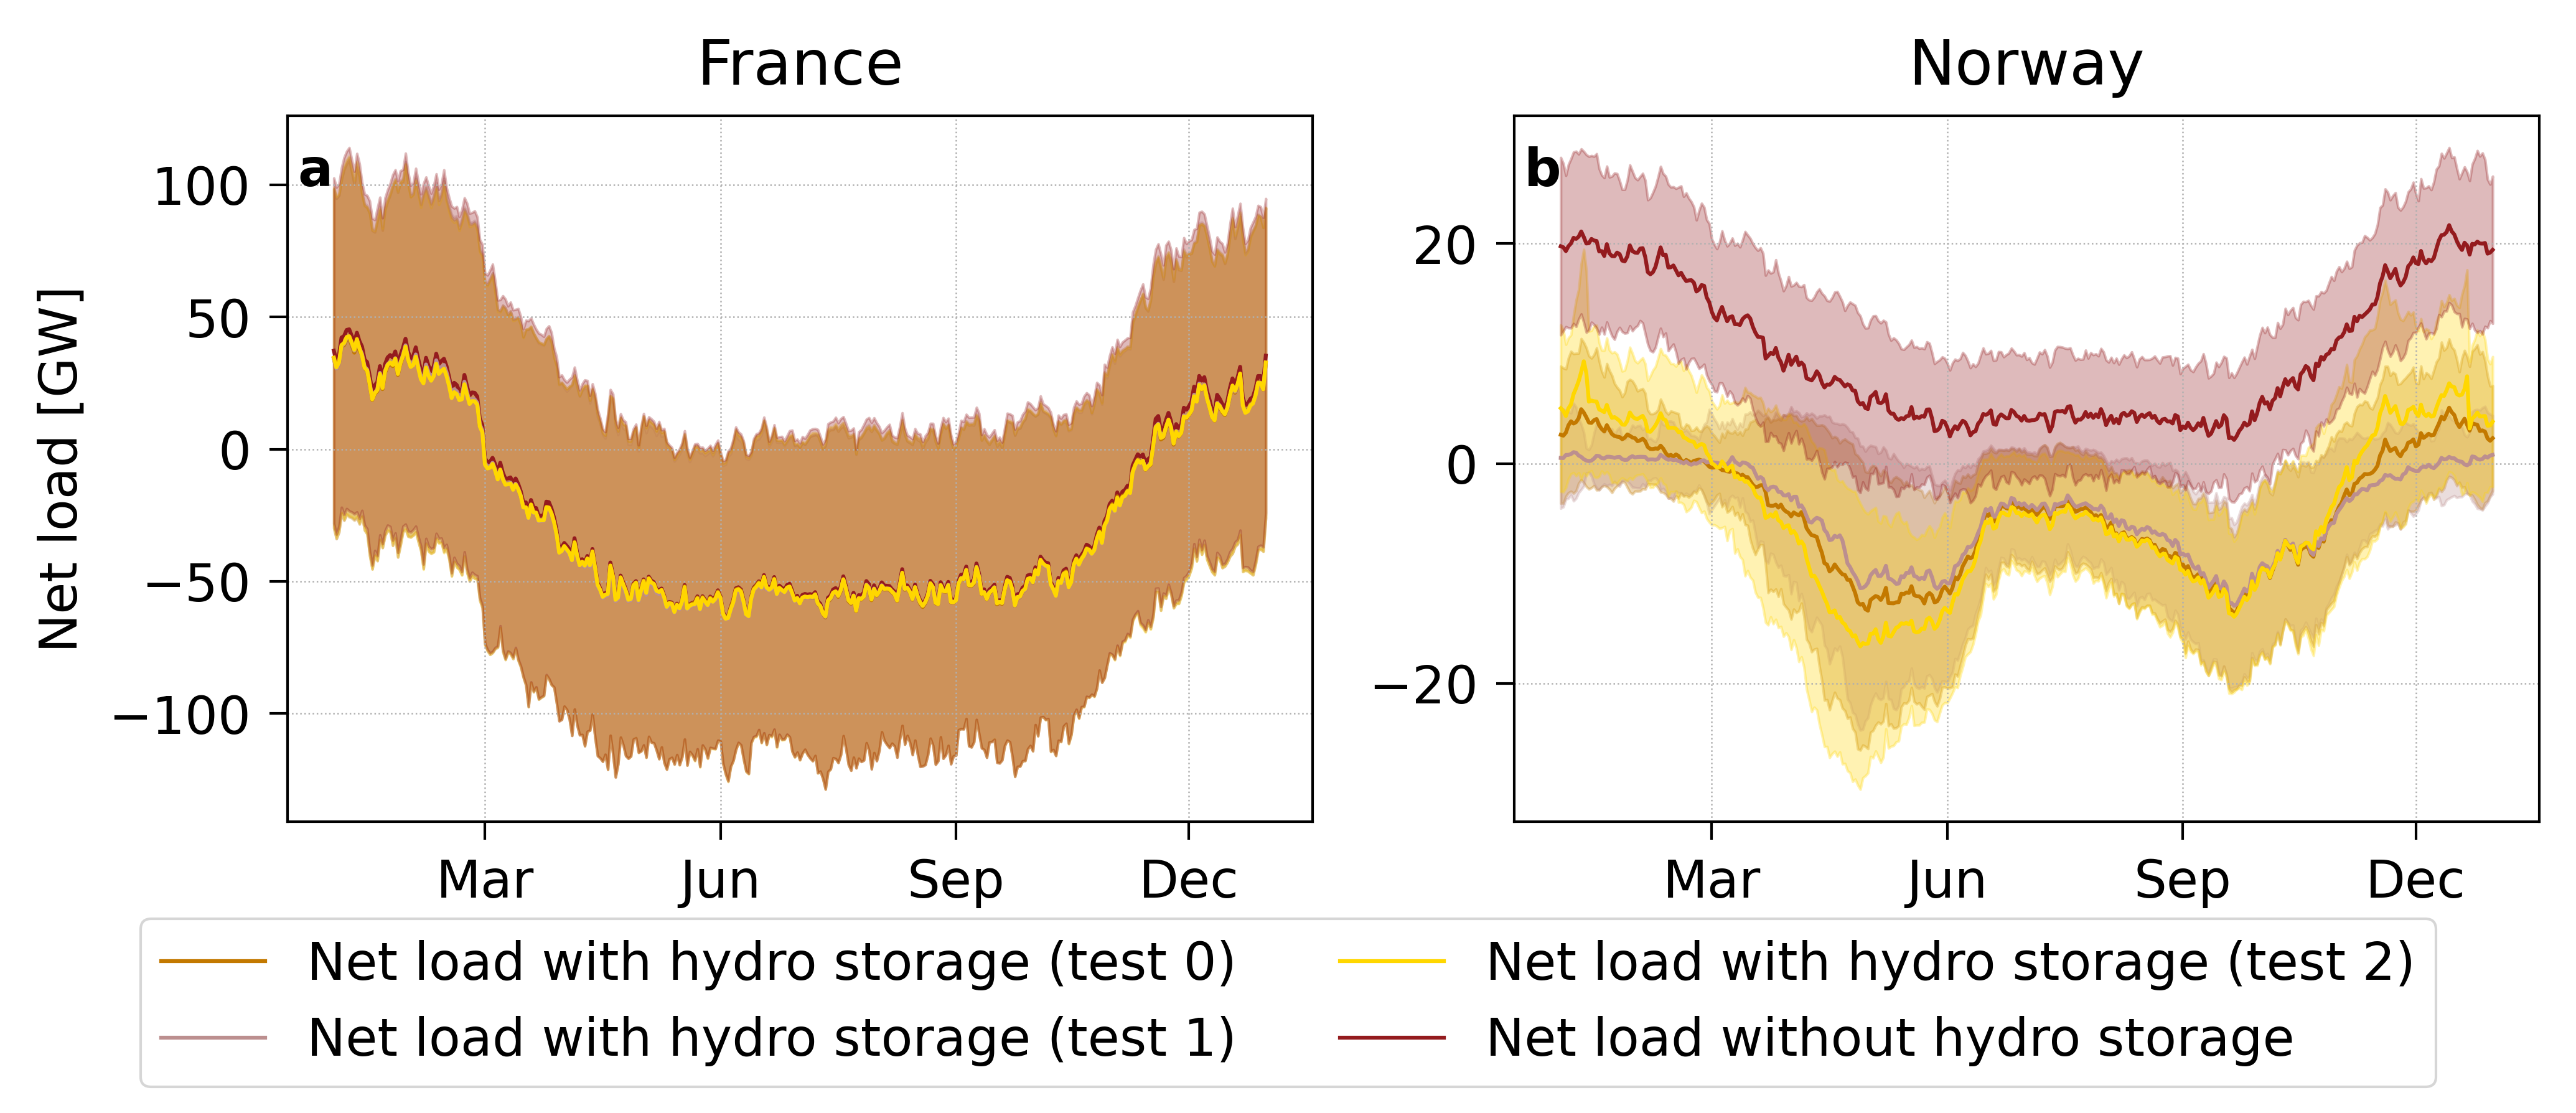

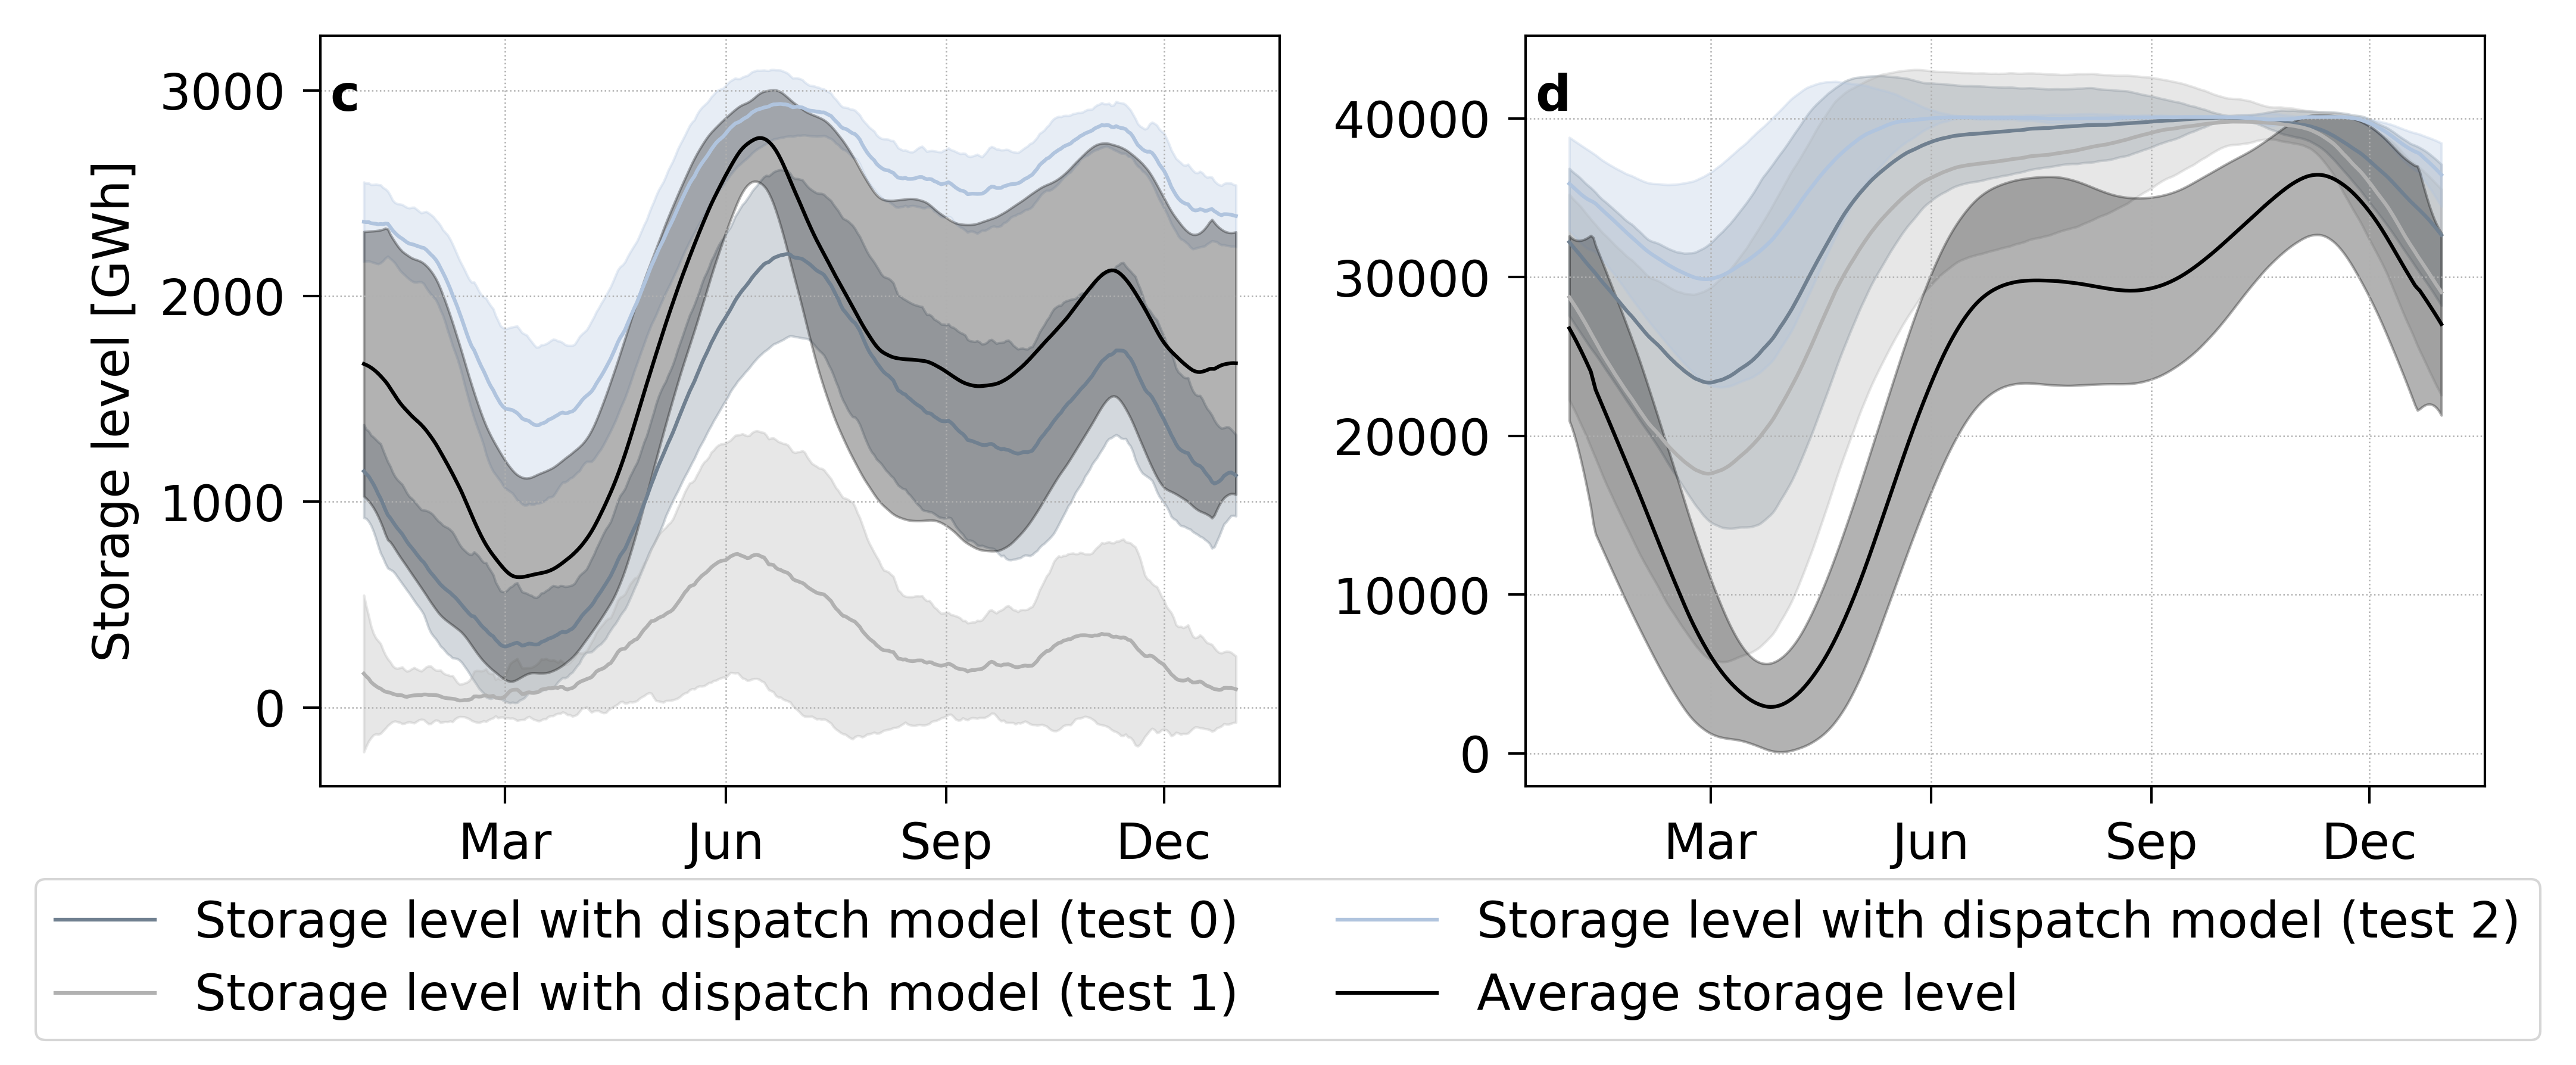

In [10]:
f1,ax1,f2,ax2= plot_hydro_storage(fsize=(7,3))
f1.savefig("../../figs_CC_impacts/hydro_storage_FR_NO_net_load_sensitivity_test.png",bbox_inches="tight", dpi = 600,transparent=True)
f2.savefig("../../figs_CC_impacts/hydro_storage_FR_NO_storage_net_load_sensitivity_test.png",bbox_inches="tight", dpi = 600,transparent=True)